# SmartCare Hospital AI Coursework
## Task 03 — Data Preprocessing and Feature Engineering

**Objective:** Create a clean and defensible dataset for predicting confirmed appointment no-shows. Only information available before the appointment is retained. Redundant engineered features are avoided to reduce overfitting risk.

## 3.1 Import Libraries and Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('smartcare_ai_dataset_1000.csv')
print('Original shape:', df.shape)
display(df.head())

Original shape: (1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,4/10/2025,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,5/15/2025,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,7/9/2025,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,10/16/2025,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,12/18/2025,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


## 3.2 Data Quality Checks

In [4]:
quality_summary = pd.DataFrame({
    'Data Type': df.dtypes.astype(str),
    'Missing Values': df.isnull().sum(),
})
display(quality_summary)

print('Full duplicate rows:', df.duplicated().sum())
print('Duplicate record IDs:', df['record_id'].duplicated().sum())
print('Duplicate patient IDs:', df['patient_id'].duplicated().sum())

,Data Type,Missing Values
record_id,int64,0
patient_id,object,0
age,int64,0
gender,object,0
blood_group,object,0
department,object,0
diagnosis,object,0
appointment_date,object,0
waiting_days,int64,0
previous_appointments,int64,0


Full duplicate rows: 0
Duplicate record IDs: 0
Duplicate patient IDs: 0


**Justification:** Missingness occurs mainly in room information, which is recorded after attendance. It is removed instead of imputed. No duplicate records are removed because all identifiers are unique.

## 3.3 Outlier Review

,IQR Outliers
age,0
waiting_days,0
previous_appointments,8
missed_previous_appointments,17
previous_admissions,60


,age,waiting_days,previous_appointments,missed_previous_appointments,previous_admissions
min,1,0,0,0,0
max,90,44,10,4,5


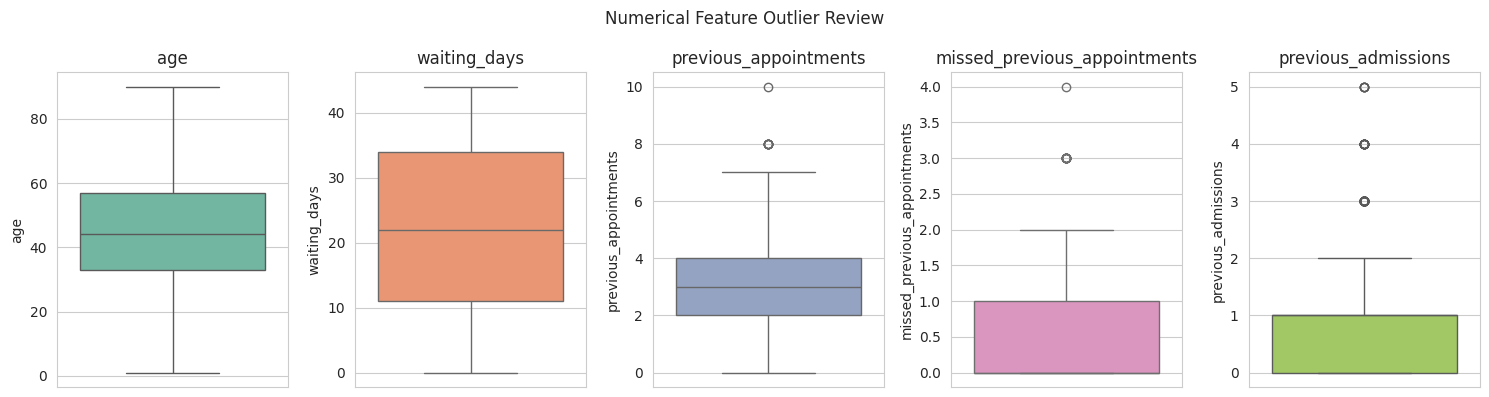

In [5]:
numeric_check = [
    'age', 'waiting_days', 'previous_appointments',
    'missed_previous_appointments', 'previous_admissions'
]

outlier_counts = {}
for column in numeric_check:
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_counts[column] = (
        (df[column] < q1 - 1.5 * iqr) |
        (df[column] > q3 + 1.5 * iqr)
    ).sum()

display(pd.Series(outlier_counts, name='IQR Outliers').to_frame())
display(df[numeric_check].agg(['min', 'max']))

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for column, axis, color in zip(
    numeric_check, axes, sns.color_palette('Set2', 5)
):
    sns.boxplot(y=df[column], ax=axis, color=color)
    axis.set_title(column)
plt.suptitle('Numerical Feature Outlier Review')
plt.tight_layout()
plt.show()

**Justification:** The flagged history values remain within realistic ranges and no impossible negative values are present. They are retained because they may represent genuine patient histories.

## 3.4 Correct the Target Population

In [6]:
display(pd.crosstab(df['appointment_status'], df['no_show']))

df_clean = df[
    df['appointment_status'].isin(['Completed', 'No-Show'])
].copy().reset_index(drop=True)
df_clean['no_show'] = (
    df_clean['appointment_status'] == 'No-Show'
).astype(int)

print('Corrected shape:', df_clean.shape)
print('Removed Scheduled and Cancelled records:', len(df) - len(df_clean))
display(df_clean['no_show'].value_counts().sort_index().to_frame('Count'))

no_show,0,1
appointment_status,,
Cancelled,53,0
Completed,380,0
No-Show,0,495
Scheduled,72,0


Corrected shape: (875, 33)
Removed Scheduled and Cancelled records: 125


,Count
no_show,
0,380
1,495


**Justification:** Scheduled appointments do not yet have an outcome, and cancelled appointments are not confirmed attendance. Keeping only Completed and No-Show records creates a clear binary target: 0 = attended and 1 = no-show.

## 3.5 Remove Leakage and Unnecessary Columns

In [7]:
drop_columns = [
    'record_id', 'patient_id', 'appointment_status',
    'gender', 'blood_group',
    'admitted', 'room_type', 'length_of_stay_days',
    'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl',
    'cholesterol_mg_dl', 'bmi', 'lab_tests_count',
    'treatments_count', 'consultation_fee_lkr',
    'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr',
    'total_bill_lkr', 'payment_status', 'payment_method',
    'readmitted_30_days', 'disease_risk_level'
]

df_model = df_clean.drop(columns=drop_columns)
print('Columns retained before encoding:', df_model.columns.tolist())

Columns retained before encoding: ['age', 'department', 'diagnosis', 'appointment_date', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'previous_admissions', 'no_show']


**Justification:** Identifiers do not describe attendance behaviour. `appointment_status` directly reveals the target. Clinical, admission, treatment, billing, and payment fields are recorded after attendance and would cause leakage. Gender and blood group are kept outside the model to reduce fairness risk.

## 3.6 Encode Booking-Time Categories

In [8]:
df_model['appointment_date'] = pd.to_datetime(df_model['appointment_date'])
df_model['appointment_month'] = df_model['appointment_date'].dt.month
df_model['appointment_dayofweek'] = df_model['appointment_date'].dt.dayofweek
df_model = df_model.drop(columns='appointment_date')

df_model = pd.get_dummies(
    df_model,
    columns=['department', 'diagnosis'],
    drop_first=True,
    dtype=int
)

print('Shape after encoding:', df_model.shape)

Shape after encoding: (875, 23)


**Justification:** Month and weekday are simple appointment-timing variables. One-hot encoding represents department and diagnosis without creating a false order. More complex date interactions are not added because the dataset is small.

## 3.7 Create Two Simple Behavioural Features

In [9]:
df_model['missed_ratio'] = np.where(
    df_model['previous_appointments'] > 0,
    df_model['missed_previous_appointments'] /
    df_model['previous_appointments'],
    0
)
df_model['has_missed_before'] = (
    df_model['missed_previous_appointments'] > 0
).astype(int)

display(df_model.groupby('has_missed_before')['no_show'].agg(['count', 'mean'])
        .rename(columns={'mean': 'No-Show Rate'}))
print('Final model dataset shape:', df_model.shape)

,count,No-Show Rate
has_missed_before,,
0,493,0.539554
1,382,0.599476


Final model dataset shape: (875, 25)


**Justification:** `missed_ratio` summarises the proportion of earlier appointments that were missed. `has_missed_before` separates patients with and without known missed history. Continuous `waiting_days` is retained directly, so `long_wait_flag`, waiting-time squares, interaction terms, and age-group duplicates are not created. This keeps the feature set small and easy to explain.

## 3.8 Preliminary Feature Relevance Review

In [10]:
target_association = (
    df_model.corr(numeric_only=True)['no_show']
    .drop('no_show')
    .sort_values(key=abs, ascending=False)
)
display(target_association.head(12).to_frame('Correlation with no_show'))

zero_variance = [
    column for column in df_model.columns
    if column != 'no_show' and df_model[column].nunique() <= 1
]
print('Zero-variance features:', zero_variance)

,Correlation with no_show
waiting_days,0.264758
missed_ratio,0.089369
previous_appointments,-0.080247
age,-0.074934
missed_previous_appointments,0.071578
has_missed_before,0.059959
appointment_dayofweek,0.059657
diagnosis_Chest Pain,0.052415
department_Neurology,0.048343
department_Orthopedics,-0.045594


Zero-variance features: []


**Justification:** This is only a preliminary review. Weak correlation does not prove that a feature is useless in a multivariable model. Supervised feature selection is performed inside Task 05 training pipelines to prevent leakage.

## 3.9 Demonstrate Scaling and Save Outputs

In [11]:
scale_columns = [
    'age', 'waiting_days', 'previous_appointments',
    'missed_previous_appointments', 'previous_admissions',
    'appointment_month', 'appointment_dayofweek', 'missed_ratio'
]

scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[scale_columns] = scaler.fit_transform(df_model[scale_columns])

fairness_columns = df_clean[['gender', 'age']].copy()
fairness_columns['age_group'] = pd.cut(
    fairness_columns['age'],
    bins=[0, 17, 39, 59, np.inf],
    labels=['0-17', '18-39', '40-59', '60+']
)

assert df_model.shape == (875, 25)
assert df_model.isnull().sum().sum() == 0

df_model.to_csv('smartcare_preprocessed_unscaled.csv', index=False)
df_scaled.to_csv('smartcare_preprocessed_scaled.csv', index=False)
fairness_columns.to_csv('fairness_columns.csv', index=False)

print('Unscaled dataset:', df_model.shape)
print('Scaled dataset:', df_scaled.shape)
print('Fairness file:', fairness_columns.shape)
print('Files saved successfully.')

Unscaled dataset: (875, 25)
Scaled dataset: (875, 25)
Fairness file: (875, 3)
Files saved successfully.


### Task 03 Summary

The final dataset contains 875 confirmed appointments, 24 model inputs, and one target. It uses only booking-time and prior-history information. Redundant engineered variables are avoided. The unscaled file is used in Tasks 04 and 05. Task 05 fits scaling and feature selection inside training-only pipelines.